
# 08. Consolidación de Resultados: Híbrido vs Líneas Base

**Objetivo:** consolidar tablas comparativas, matrices de confusión, gráficos y ablaciones para el manuscrito.
**Entradas (inputs):** `data/*_eval.csv` (líneas base) y `data/outputs/train_<run_id>/*` generado por 07.
**Salidas (outputs):** `data/outputs/results_<run_id>/tabla_comparativa_modelos.csv`, `figures/*.png`, `indice_matrices_confusion.csv`, `resumen_resultados.json`.
**Notebook anterior:** `notebooks/pipeline/04a_linea_base_dummy.ipynb`, `04b_linea_base_tfidf.ipynb`, `04c_linea_base_transformers.ipynb`, `07_entrenamiento_modelos_hibridos.ipynb`.
**Notebook siguiente:** `notebooks/pipeline/09b_cierre_modelos_dev.ipynb` y `notebooks/analysis/09_analisis_errores_hibrido.ipynb`.

> **Contrato de comparabilidad:** este notebook solo mantiene en la tabla final modelos evaluados sobre el mismo split denoised y el mismo `n_eval` del híbrido.


## Técnicas, herramientas y librerías de esta etapa

- **Técnica principal:** consolidación de métricas, tablas comparativas y visualización de resultados comparables en `dev`.
- **Herramientas/librerías:** `pandas`, `numpy`, `matplotlib`, métricas de `scikit-learn`.
- **Por qué es adecuada aquí:** esta etapa no crea modelos nuevos; ordena evidencia comparable entre líneas base e híbridos y evita conclusiones apoyadas solo en una tabla dispersa.
- **Limitación:** no reemplaza el cierre formal multicriterio de `09b` ni la lectura clínica de errores en `09`.
- **Alternativa posible:** librerías de visualización más ricas como `seaborn` o `plotly` serían válidas, pero el cuello de botella no es estético sino metodológico.


## Criterio de comparabilidad metodológica (08)

Este notebook consolida resultados **solo si son metodológicamente comparables** con el híbrido entrenado en 07.

Reglas de comparabilidad aplicadas:
- mismo `eval_split` del híbrido (`dev` o `test`);
- mismo `n_eval` esperado para ese split denoised;
- exclusión explícita de líneas base fuera de contrato.

Además, se preserva trazabilidad por `run_id` para enlazar tablas, matrices de confusión y predicciones por fila.


In [1]:

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, balanced_accuracy_score

from utils_shared import setup_paths, ensure_dir, latest_train_run

paths = setup_paths()
DATA_PATH = paths['DATA_PATH']
OUTPUTS_PATH = paths['OUTPUTS_PATH']

# Selección de corrida de entrenamiento base.
# Por defecto se prioriza la última corrida canónica train_YYYYMMDD_HHMMSS
# para no confundirla con corridas hijas del barrido/ablación.
TRAIN_RUN_ID = os.getenv('RESULTS_TRAIN_RUN_ID') or None
if TRAIN_RUN_ID is None:
    TRAIN_RUN_ID = latest_train_run(OUTPUTS_PATH)
    if TRAIN_RUN_ID is None:
        raise FileNotFoundError('No se encontraron carpetas train_* en data/outputs')

TRAIN_DIR = OUTPUTS_PATH / TRAIN_RUN_ID
print('TRAIN_DIR:', TRAIN_DIR)

RESULTS_RUN_ID = os.getenv('RESULTS_RUN_ID') or pd.Timestamp.now().strftime('results_%Y%m%d_%H%M%S')
RESULTS_DIR = ensure_dir(OUTPUTS_PATH / RESULTS_RUN_ID)
FIG_DIR = ensure_dir(RESULTS_DIR / 'figures')
print('RESULTS_DIR:', RESULTS_DIR)


TRAIN_DIR: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/train_20260512_165340
RESULTS_DIR: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260512_171915


In [2]:
# Cargar métricas de líneas base
baseline_files = {
    'dummy': DATA_PATH / 'dummy_eval.csv',
    'tfidf': DATA_PATH / 'tfidf_eval.csv',
    'beto': DATA_PATH / 'beto_eval.csv',
    'roberta_biomedical': DATA_PATH / 'roberta_biomedical_eval.csv',
    'roberta_clinical': DATA_PATH / 'roberta_clinical_eval.csv',
}

baseline_rows = []
for nombre, fpath in baseline_files.items():
    if not fpath.exists():
        continue
    df = pd.read_csv(fpath)
    if df.empty:
        continue
    row = df.iloc[0].to_dict()
    row['source'] = 'baseline_texto'
    row['profile'] = 'texto'
    row['model'] = str(row.get('modelo', nombre)).upper()
    baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows)
print('Baselines cargados:', len(baseline_df))


Baselines cargados: 5


In [3]:
# Cargar métricas híbridas
# Estas métricas provienen de artefactos exportados por el notebook 07.

cand_h = sorted(TRAIN_DIR.glob('comparacion_modelos_*.csv'), key=lambda p: p.stat().st_mtime)
if not cand_h:
    raise FileNotFoundError(f'No se encontró comparacion_modelos_*.csv en {TRAIN_DIR}')

hybrid_path = cand_h[-1]
hybrid_df = pd.read_csv(hybrid_path)
hybrid_df['source'] = 'hibrido'

train_meta = {}
train_meta_path = TRAIN_DIR / 'resumen_entrenamiento.json'
if train_meta_path.exists():
    try:
        train_meta = json.loads(train_meta_path.read_text(encoding='utf-8'))
    except Exception as e:
        print('Aviso: no se pudo leer resumen_entrenamiento.json:', e)

# Normalización de nombres
rename_map = {
    'f1': 'f1_macro',
    'macro_f1': 'f1_macro',
    'macro_f1_score': 'f1_macro',
    'balanced_accuracy': 'balanced_acc',
    'modelo': 'model',
}
baseline_df = baseline_df.rename(columns=rename_map)
hybrid_df = hybrid_df.rename(columns=rename_map)

# Evitar ambigüedad por columnas duplicadas (ej. modelo/model)
baseline_df = baseline_df.loc[:, ~baseline_df.columns.duplicated()].copy()
hybrid_df = hybrid_df.loc[:, ~hybrid_df.columns.duplicated()].copy()

for df in (baseline_df, hybrid_df):
    if 'model' in df.columns:
        df['model'] = df['model'].astype(str).str.upper()


# Backbone contextual y metadatos de trazabilidad
if 'text_backbone' not in hybrid_df.columns:
    hybrid_df['text_backbone'] = train_meta.get('feature_text_backbone', np.nan)
if 'context_prefixes' not in hybrid_df.columns:
    pref = train_meta.get('feature_context_prefixes', [])
    if isinstance(pref, list):
        pref = '|'.join(pref)
    hybrid_df['context_prefixes'] = pref if pref else np.nan
if 'contexto_activo' not in hybrid_df.columns:
    hybrid_df['contexto_activo'] = train_meta.get('train_use_context', train_meta.get('train_use_beto', np.nan))

if 'text_backbone' not in baseline_df.columns:
    baseline_df['text_backbone'] = np.nan
if 'context_prefixes' not in baseline_df.columns:
    baseline_df['context_prefixes'] = np.nan
if 'contexto_activo' not in baseline_df.columns:
    baseline_df['contexto_activo'] = np.nan

if 'model' in baseline_df.columns:
    m = baseline_df['model'].astype(str).str.upper()
    baseline_df.loc[m.eq('BETO'), 'text_backbone'] = 'beto'
    baseline_df.loc[m.eq('ROBERTA_CLINICAL'), 'text_backbone'] = 'roberta_clinical'
    baseline_df.loc[m.eq('ROBERTA_BIOMEDICAL'), 'text_backbone'] = 'roberta_biomedical'


# Consolidar tamaño de evaluación baseline sin perder información de columnas legacy
if 'n_eval' not in baseline_df.columns:
    baseline_df['n_eval'] = np.nan
for aux_col in ['n_dev', 'n_test']:
    if aux_col in baseline_df.columns:
        mask_aux = baseline_df['n_eval'].isna() & baseline_df[aux_col].notna()
        baseline_df.loc[mask_aux, 'n_eval'] = baseline_df.loc[mask_aux, aux_col]


# Completar métricas híbridas desde predicciones exportadas por 07
for col in ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'balanced_acc', 'n_eval', 'eval_split']:
    if col not in hybrid_df.columns:
        hybrid_df[col] = np.nan

for idx, row in hybrid_df.iterrows():
    profile = str(row.get('profile', '')).strip().lower()
    model = str(row.get('model', '')).strip().lower()
    split = str(row.get('eval_split', 'dev')).strip().lower()
    if split in {'', 'nan', 'none'}:
        split = 'dev'

    pred_path = TRAIN_DIR / f'predicciones_{profile}_{model}_{split}.csv'
    if not pred_path.exists():
        continue

    dfp = pd.read_csv(pred_path)
    if not {'y_true', 'y_pred'}.issubset(dfp.columns):
        continue

    y_true = dfp['y_true'].astype(str)
    y_pred = dfp['y_pred'].astype(str)

    m = {
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'n_eval': len(dfp),
        'eval_split': split,
    }

    for col, val in m.items():
        if pd.isna(hybrid_df.at[idx, col]):
            hybrid_df.at[idx, col] = val

# Definir contrato esperado desde el híbrido
expected_split = None
if 'eval_split' in hybrid_df.columns and hybrid_df['eval_split'].notna().any():
    expected_split = str(hybrid_df['eval_split'].dropna().astype(str).mode().iloc[0]).lower()
if expected_split in {'', 'nan', 'none', None}:
    expected_split = str(train_meta.get('eval_on', 'dev')).strip().lower() or 'dev'

expected_n_eval = np.nan
expected_path = paths['SPLITS_PATH'] / f'{expected_split}_denoised.csv'
if expected_path.exists():
    try:
        expected_n_eval = len(pd.read_csv(expected_path))
    except Exception:
        pass

print('Contrato esperado -> split:', expected_split, '| n_eval:', expected_n_eval)

# Completar métricas baseline para evitar NaN no informativos
for col in ['balanced_acc', 'n_eval', 'eval_split', 'cv_macro_f1']:
    if col not in baseline_df.columns:
        baseline_df[col] = np.nan

# En este problema, balanced accuracy equivale al promedio de recall por clase
if {'balanced_acc', 'recall_macro'}.issubset(baseline_df.columns):
    msk_ba = baseline_df['balanced_acc'].isna() & baseline_df['recall_macro'].notna()
    baseline_df.loc[msk_ba, 'balanced_acc'] = baseline_df.loc[msk_ba, 'recall_macro']

baseline_df['eval_split'] = baseline_df['eval_split'].fillna(expected_split)
baseline_df['n_eval'] = pd.to_numeric(baseline_df['n_eval'], errors='coerce')
if not pd.isna(expected_n_eval):
    baseline_df['n_eval'] = baseline_df['n_eval'].fillna(float(expected_n_eval))

# Filtrar baselines que no cumplen el contrato de comparabilidad
if not baseline_df.empty:
    m_split = baseline_df['eval_split'].astype(str).str.lower() == expected_split
    if pd.isna(expected_n_eval):
        m_n = pd.Series([True] * len(baseline_df), index=baseline_df.index)
    else:
        m_n = baseline_df['n_eval'].astype(float) == float(expected_n_eval)

    comparable_mask = m_split & m_n
    dropped = baseline_df.loc[~comparable_mask, ['model', 'eval_split', 'n_eval']].copy()
    if not dropped.empty:
        print('Aviso: se excluyen baselines no comparables con el contrato del híbrido:')
        print(dropped.to_string(index=False))

    baseline_df = baseline_df.loc[comparable_mask].copy()

# Marcar explícitamente disponibilidad de CV
baseline_df['cv_macro_f1'] = baseline_df['cv_macro_f1'].fillna('no_aplica')
hybrid_df['cv_macro_f1'] = hybrid_df['cv_macro_f1'].fillna('no_disponible')

if 'model' in hybrid_df.columns:
    modelos_h = set(hybrid_df['model'].dropna().astype(str).str.upper().unique())
    if 'RF' not in modelos_h:
        print('Aviso: no se encontraron filas RF en comparacion_modelos_*.csv')
    if train_meta.get('use_xgb', True) and 'XGB' not in modelos_h:
        print('Aviso: se esperaba XGB pero no se encontraron filas XGB en comparacion_modelos_*.csv')

# Armar tabla consolidada para comparación principal
cols_keep = [
    'source', 'profile', 'model', 'text_backbone', 'context_prefixes', 'contexto_activo',
    'f1_macro', 'balanced_acc', 'precision_macro', 'recall_macro',
    'accuracy', 'cv_macro_f1', 'n_train', 'n_eval', 'eval_split'
]

def keep_available(df):
    return df[[c for c in cols_keep if c in df.columns]].copy()

frames = []
if not baseline_df.empty:
    frames.append(keep_available(baseline_df))
if not hybrid_df.empty:
    frames.append(keep_available(hybrid_df))

if not frames:
    raise ValueError('No hay métricas disponibles para consolidar.')

consolidado = pd.concat(frames, ignore_index=True)
consolidado_path = RESULTS_DIR / 'tabla_comparativa_modelos.csv'
consolidado.to_csv(consolidado_path, index=False)
print('Guardado:', consolidado_path)

display(consolidado.sort_values('f1_macro', ascending=False))


Contrato esperado -> split: dev | n_eval: 343
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260512_171915/tabla_comparativa_modelos.csv


/var/folders/25/fy01l91x3gj63g090ghxj7000000gn/T/ipykernel_73848/1270414164.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'beto' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  baseline_df.loc[m.eq('BETO'), 'text_backbone'] = 'beto'


,source,profile,model,text_backbone,context_prefixes,contexto_activo,f1_macro,balanced_acc,precision_macro,recall_macro,accuracy,cv_macro_f1,n_train,n_eval,eval_split
4,baseline_texto,texto,ROBERTA_CLINICAL,roberta_clinical,NaN,NaN,0.741078,0.763889,0.732286,0.763889,0.769679,no_aplica,1107,343,dev
1,baseline_texto,texto,TFIDF,NaN,NaN,NaN,0.740564,0.767716,0.732290,0.767716,0.766764,no_aplica,1107,343,dev
2,baseline_texto,texto,BETO,beto,NaN,NaN,0.735052,0.749177,0.727153,0.749177,0.769679,no_aplica,1107,343,dev
8,hibrido,py,XGB,beto,ctx_beto_,1.0,0.723387,0.717099,0.731686,0.717099,0.778426,0.654164,1107,343,dev
3,baseline_texto,texto,ROBERTA_BIOMEDICAL,roberta_biomedical,NaN,NaN,0.722794,0.730350,0.717362,0.730350,0.763848,no_aplica,1107,343,dev
6,hibrido,core,XGB,beto,ctx_beto_,1.0,0.709612,0.702099,0.720501,0.702099,0.769679,0.651851,1107,343,dev
7,hibrido,py,RF,beto,ctx_beto_,1.0,0.699626,0.707119,0.694535,0.707119,0.743440,0.661844,1107,343,dev
5,hibrido,core,RF,beto,ctx_beto_,1.0,0.684995,0.693889,0.679691,0.693889,0.728863,0.659421,1107,343,dev
0,baseline_texto,texto,DUMMY,NaN,NaN,NaN,0.494237,0.494506,0.494766,0.494506,0.571429,no_aplica,1107,343,dev


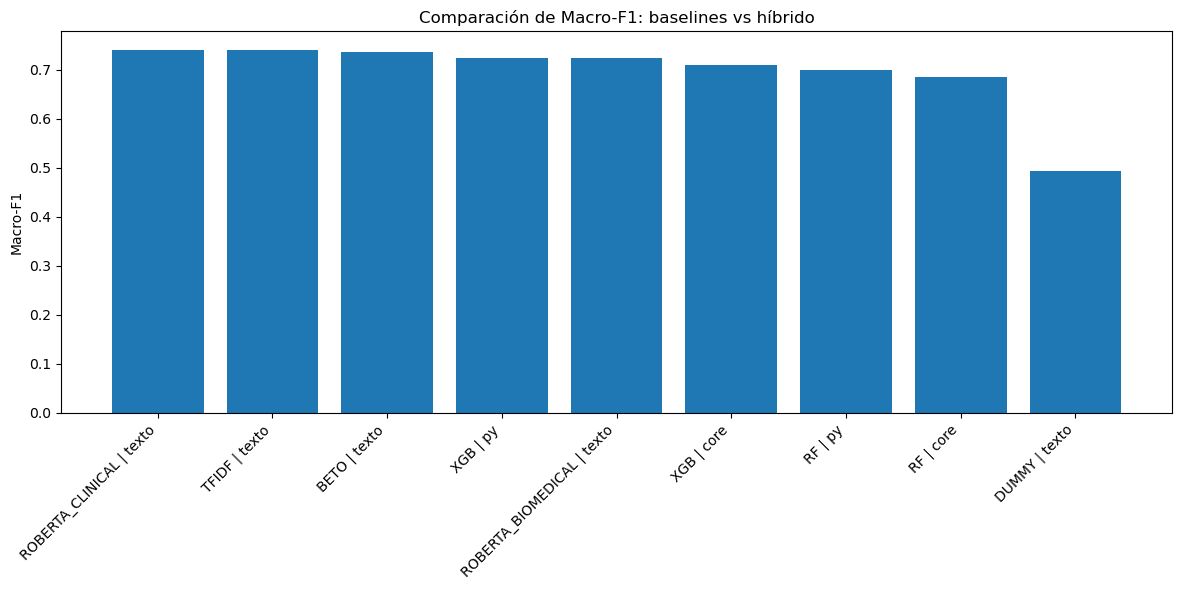

Figura: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260512_171915/figures/comparacion_macro_f1.png


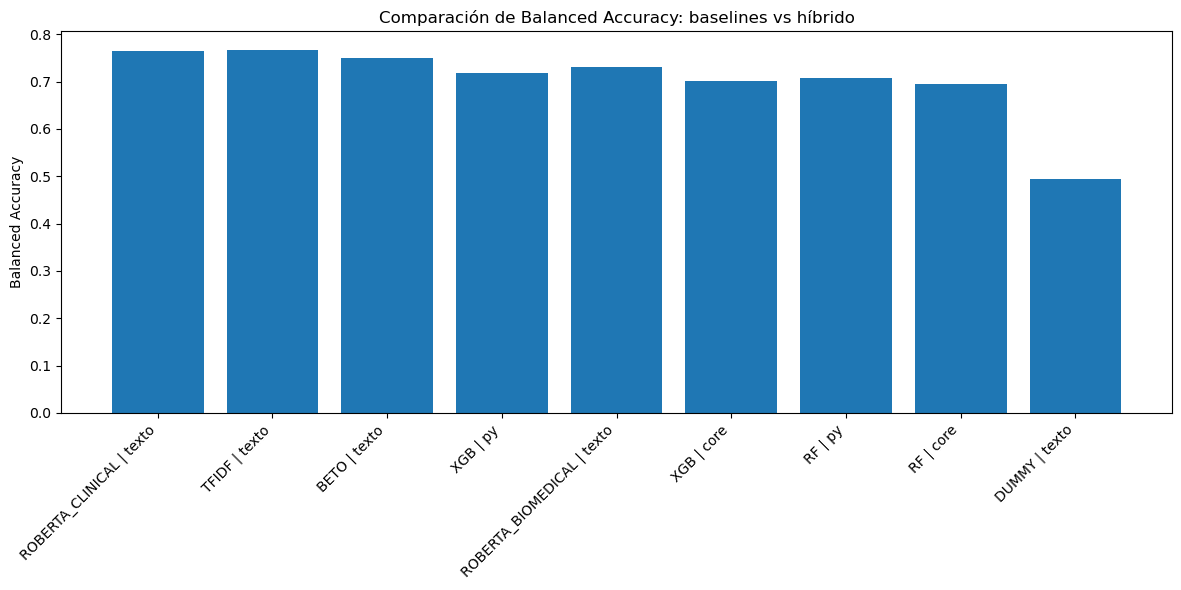

Figura: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260512_171915/figures/comparacion_balanced_accuracy.png


In [4]:
# Gráfico de Macro-F1
plot_df = consolidado.dropna(subset=['f1_macro']).copy()
if plot_df.empty:
    print('Aviso: No hay filas con f1_macro para graficar.')
else:
    plot_df['etiqueta_modelo'] = plot_df['model'] + ' | ' + plot_df['profile'].astype(str)
    plot_df = plot_df.sort_values('f1_macro', ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(plot_df['etiqueta_modelo'], plot_df['f1_macro'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Macro-F1')
    plt.title('Comparación de Macro-F1: baselines vs híbrido')
    plt.tight_layout()
    fig_f1 = FIG_DIR / 'comparacion_macro_f1.png'
    plt.savefig(fig_f1, dpi=200)
    plt.show()
    print('Figura:', fig_f1)

    # Gráfico de Balanced Accuracy
    if 'balanced_acc' in plot_df.columns:
        bdf = plot_df.dropna(subset=['balanced_acc']).copy()
        if not bdf.empty:
            plt.figure(figsize=(12, 6))
            plt.bar(bdf['etiqueta_modelo'], bdf['balanced_acc'])
            plt.xticks(rotation=45, ha='right')
            plt.ylabel('Balanced Accuracy')
            plt.title('Comparación de Balanced Accuracy: baselines vs híbrido')
            plt.tight_layout()
            fig_ba = FIG_DIR / 'comparacion_balanced_accuracy.png'
            plt.savefig(fig_ba, dpi=200)
            plt.show()
            print('Figura:', fig_ba)


In [5]:
# Ablación core vs py (solo híbrido)
if not hybrid_df.empty and {'profile', 'model', 'f1_macro'}.issubset(hybrid_df.columns):
    abl = hybrid_df.pivot_table(index='model', columns='profile', values='f1_macro', aggfunc='mean').reset_index()
    if {'core', 'py'}.issubset(set(abl.columns)):
        abl['delta_py_vs_core'] = abl['py'] - abl['core']
    abl_path = RESULTS_DIR / 'ablacion_core_vs_py.csv'
    abl.to_csv(abl_path, index=False)
    print('Guardado:', abl_path)
    display(abl)


Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260512_171915/ablacion_core_vs_py.csv


profile,model,core,py,delta_py_vs_core
0,RF,0.684995,0.699626,0.014631
1,XGB,0.709612,0.723387,0.013775


In [6]:
# Matrices de confusión desde predicciones exportadas por 07
pred_files = sorted(TRAIN_DIR.glob('predicciones_*_*.csv'))
cm_rows = []

for p in pred_files:
    dfp = pd.read_csv(p)
    if not {'y_true', 'y_pred'}.issubset(dfp.columns):
        continue

    labels = sorted(pd.Series(list(set(dfp['y_true']) | set(dfp['y_pred']))).astype(str).unique())
    cm = confusion_matrix(dfp['y_true'].astype(str), dfp['y_pred'].astype(str), labels=labels)
    cmn = confusion_matrix(dfp['y_true'].astype(str), dfp['y_pred'].astype(str), labels=labels, normalize='true')

    base = p.stem
    cm_csv = RESULTS_DIR / f'{base}_matriz_confusion.csv'
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(cm_csv)

    plt.figure(figsize=(7, 6))
    plt.imshow(cmn)
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.yticks(range(len(labels)), labels)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(f'Matriz de confusión normalizada | {base}')
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    cm_fig = FIG_DIR / f'{base}_matriz_confusion.png'
    plt.savefig(cm_fig, dpi=200)
    plt.close()

    cm_rows.append({'archivo_predicciones': p.name, 'matriz_csv': cm_csv.name, 'figura': cm_fig.name})

cm_index = pd.DataFrame(cm_rows)
cm_index_path = RESULTS_DIR / 'indice_matrices_confusion.csv'
cm_index.to_csv(cm_index_path, index=False)
print('Guardado:', cm_index_path)


Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260512_171915/indice_matrices_confusion.csv


In [7]:
# Resumen de ejecución final para manuscrito
resumen = {}
if not consolidado.empty and 'f1_macro' in consolidado.columns:
    top = consolidado.sort_values('f1_macro', ascending=False).iloc[0].to_dict()
    resumen['mejor_modelo'] = top

resumen['train_run_id_origen'] = TRAIN_RUN_ID
resumen['results_run_id'] = RESULTS_RUN_ID
resumen['comparacion_hibrida_origen'] = hybrid_path.name


# Selección Transformer de 04c para trazabilidad
sel_latest = OUTPUTS_PATH / 'transformer_baseline_selection_latest.json'
if sel_latest.exists():
    try:
        sel_payload = json.loads(sel_latest.read_text(encoding='utf-8'))
        resumen['transformer_baseline_selection_path'] = str(sel_latest)
        resumen['transformer_baseline_seleccionado_04c'] = (sel_payload.get('mejor_transformer_baseline', {}) or {}).get('modelo')
    except Exception as e:
        print('Aviso: no se pudo leer selección Transformer latest:', e)

if not baseline_df.empty and 'model' in baseline_df.columns:
    trf = baseline_df[baseline_df['model'].astype(str).str.upper().isin(['BETO', 'ROBERTA_CLINICAL', 'ROBERTA_BIOMEDICAL'])].copy()
    if not trf.empty:
        trf_top = trf.sort_values('f1_macro', ascending=False).iloc[0].to_dict()
        resumen['mejor_transformer_baseline_en_tabla'] = trf_top

resumen_path = RESULTS_DIR / 'resumen_resultados.json'
with open(resumen_path, 'w', encoding='utf-8') as f:
    json.dump(resumen, f, ensure_ascii=False, indent=2)

print('Resumen:', resumen_path)
print('Consolidación finalizada.')


Resumen: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260512_171915/resumen_resultados.json
Consolidación finalizada.


## Lectura interpretativa mínima para validación clínica

La tabla comparativa no debe leerse solo como ranking:

- `TF-IDF` funciona como baseline léxico-estadístico fuerte y parsimonioso;
- `ROBERTA_CLINICAL` resume el mejor baseline contextual standalone en `dev`;
- el híbrido final no se selecciona por ganar en métrica pura, sino por combinar señal contextual con trazabilidad clínica y reglas reutilizables.

La comparación clínica más curada entre estos enfoques, incluyendo solapamiento de aciertos y casos exclusivos, se centraliza en `10_validacion_clinica_ips.ipynb`.


## Cierre dev ensamble por ramas alineado

Esta sección formaliza el candidato de ensamble en `dev` usando `max_length=512` para los Transformers standalone y para la rama contextual. Esta es la condición experimental donde el ensamble por ramas mostró mejora frente a `ROBERTA_CLINICAL` standalone.

No reentrena el híbrido tabular ni modifica reglas clínicas. Antes de combinar ramas, valida alineación estricta por `row_id`, orden de filas, etiquetas y columnas de probabilidad.

Salidas principales: `data/outputs/cierre_dev_ensamble_<timestamp>/reporte_cierre_dev_ensamble.md`, `manifest.json`, `tabla_experimentos_dev_cierre.csv`, matrices de confusión, métricas por clase, predicciones oficiales del ensamble y controles de hard voting.


In [8]:

# Cierre dev ensamble por ramas alineado a max_length=512
import re
import subprocess
from sklearn.metrics import classification_report

LABELS = ['ansiedad', 'depresion']
PROB_COLS = ['prob_ansiedad', 'prob_depresion']
MAX_LENGTH_CIERRE = 512
HIDDEN_SIZE_ROBERTA = 768

CIERRE_RUN_ID = os.getenv('CIERRE_DEV_ENSAMBLE_RUN_ID') or pd.Timestamp.now().strftime('cierre_dev_ensamble_512_%Y%m%d_%H%M%S')
CIERRE_DIR = ensure_dir(OUTPUTS_PATH / CIERRE_RUN_ID)
CIERRE_FIG_DIR = ensure_dir(CIERRE_DIR / 'figures')
print('CIERRE_DIR:', CIERRE_DIR)

DEV_PATH = paths['SPLITS_PATH'] / 'dev_denoised.csv'
dev_df = pd.read_csv(DEV_PATH)
base = dev_df[['row_id', 'etiqueta']].copy()
base['row_id'] = base['row_id'].astype(int)
base_row_ids = base['row_id'].tolist()
base_labels = base['etiqueta'].astype(str).tolist()

# Ramas del ensamble formal. Las ramas tabulares se reutilizan porque ya están alineadas
# por row_id y no dependen de max_length; la rama contextual usa ROBERTA_CLINICAL 512.
BRANCH_SPECS = [
    {
        'key': f'ctx_roberta_clinical_{MAX_LENGTH_CIERRE}',
        'nombre': f'ROBERTA_CLINICAL max_length={MAX_LENGTH_CIERRE}',
        'tipo': 'contextual',
        'algoritmo': 'Transformer fine-tuned standalone',
        'path': DATA_PATH / 'roberta_clinical_predicciones_dev.csv',
        'peso': 0.80,
        'max_length': MAX_LENGTH_CIERRE,
        'hidden_size': HIDDEN_SIZE_ROBERTA,
        'model_id': 'PlanTL-GOB-ES/roberta-base-biomedical-clinical-es',
    },
    {
        'key': 'simbolico_py_rf',
        'nombre': 'Simbólico regionalizado py RF balanceado',
        'tipo': 'simbolica_regionalizada',
        'algoritmo': 'RandomForest sobre Concept_Core + Concept_PY',
        'path': OUTPUTS_PATH / 'train_A_llm0_sent0_beto0_tpl0_20260401_112720' / 'predicciones_py_rf_dev.csv',
        'peso': 0.10,
        'max_length': None,
        'hidden_size': None,
        'model_id': None,
    },
    {
        'key': 'simbolico_core_rf_late_fusion_llm',
        'nombre': 'Simbólico core RF con late fusion LLM',
        'tipo': 'simbolica_core_late_fusion_llm',
        'algoritmo': 'RandomForest tabular; LLM solo normaliza señales feat_* / feat_niega_*',
        'path': OUTPUTS_PATH / 'train_A_llm1_sent0_beto0_tpl0_20260401_112720' / 'predicciones_core_rf_dev.csv',
        'peso': 0.10,
        'max_length': None,
        'hidden_size': None,
        'model_id': None,
    },
]


def git_out(args):
    try:
        return subprocess.check_output(args, cwd=Path.cwd(), text=True, stderr=subprocess.DEVNULL).strip()
    except Exception:
        return ''


def rel(path):
    try:
        return str(Path(path).relative_to(Path.cwd()))
    except Exception:
        return str(path)


def load_predicciones_alineadas(spec):
    path = Path(spec['path'])
    if not path.exists():
        raise FileNotFoundError(f"No existe predicción de rama {spec['key']}: {path}")
    df = pd.read_csv(path).copy()
    required = {'row_id', 'y_true', 'y_pred', *PROB_COLS}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} no contiene columnas requeridas: {sorted(missing)}")
    df['row_id'] = df['row_id'].astype(int)
    ids = df['row_id'].tolist()
    check = {
        'rama': spec['key'],
        'archivo': str(path),
        'n_eval': int(len(df)),
        'n_row_id_unicos': int(df['row_id'].nunique()),
        'mismo_conjunto_row_id': set(ids) == set(base_row_ids),
        'mismo_orden_row_id': ids == base_row_ids,
        'sin_duplicados_row_id': len(ids) == len(set(ids)),
        'misma_y_true_que_dev': df['y_true'].astype(str).tolist() == base_labels,
        'clases_y_true': '|'.join(sorted(df['y_true'].astype(str).unique())),
        'clases_y_pred': '|'.join(sorted(df['y_pred'].astype(str).unique())),
        'prob_cols_orden': '|'.join(PROB_COLS),
        'probabilidades_sin_na': bool(df[PROB_COLS].notna().all().all()),
        'prob_sum_min': float((df['prob_ansiedad'] + df['prob_depresion']).min()),
        'prob_sum_max': float((df['prob_ansiedad'] + df['prob_depresion']).max()),
        'peso': float(spec['peso']),
        'max_length': spec.get('max_length'),
        'hidden_size': spec.get('hidden_size'),
    }
    checks_ok = [
        check['n_eval'] == len(base_row_ids),
        check['n_row_id_unicos'] == len(base_row_ids),
        check['mismo_conjunto_row_id'],
        check['mismo_orden_row_id'],
        check['sin_duplicados_row_id'],
        check['misma_y_true_que_dev'],
        check['probabilidades_sin_na'],
        abs(check['prob_sum_min'] - 1.0) < 1e-5,
        abs(check['prob_sum_max'] - 1.0) < 1e-5,
    ]
    check['alineacion_ok'] = bool(all(checks_ok))
    if not check['alineacion_ok']:
        raise ValueError(f"Fallo de alineación en rama {spec['key']}: {check}")
    return df, check

loaded = {}
checks = []
for spec in BRANCH_SPECS:
    df_branch, check = load_predicciones_alineadas(spec)
    loaded[spec['key']] = df_branch
    checks.append(check)

check_df = pd.DataFrame(checks)
check_path = CIERRE_DIR / 'check_alineacion_ensamble.csv'
check_df.to_csv(check_path, index=False)
display(check_df)
print('Check alineación:', check_path)

# Weighted soft voting oficial.
weights = {spec['key']: float(spec['peso']) for spec in BRANCH_SPECS}
weight_sum = sum(weights.values())
weights = {k: v / weight_sum for k, v in weights.items()}

ens = base.rename(columns={'etiqueta': 'y_true'}).copy()
ens['prob_ansiedad'] = 0.0
ens['prob_depresion'] = 0.0
for spec in BRANCH_SPECS:
    key = spec['key']
    branch = loaded[key][['row_id', 'y_pred', *PROB_COLS]].rename(columns={
        'y_pred': f'y_pred__{key}',
        'prob_ansiedad': f'prob_ansiedad__{key}',
        'prob_depresion': f'prob_depresion__{key}',
    })
    ens = ens.merge(branch, on='row_id', how='left')
    ens['prob_ansiedad'] += ens[f'prob_ansiedad__{key}'] * weights[key]
    ens['prob_depresion'] += ens[f'prob_depresion__{key}'] * weights[key]

ens['y_pred'] = np.where(ens['prob_ansiedad'] >= ens['prob_depresion'], 'ansiedad', 'depresion')
branch_cols = [c for c in ens.columns if c.startswith('y_pred__') or (c.startswith('prob_') and '__' in c)]
ens = ens[['row_id', 'y_true', 'y_pred', 'prob_ansiedad', 'prob_depresion'] + branch_cols]
pred_ens_path = CIERRE_DIR / 'predicciones_ensamble_dev.csv'
ens.to_csv(pred_ens_path, index=False)
print('Predicciones ensamble:', pred_ens_path)

# Hard voting como control simple.
def hard_vote_simple(row):
    votos = [row[f'y_pred__{spec["key"]}'] for spec in BRANCH_SPECS]
    counts = {lab: votos.count(lab) for lab in LABELS}
    return max(LABELS, key=lambda lab: (counts[lab], -LABELS.index(lab)))

def hard_vote_ponderado(row):
    scores = {lab: 0.0 for lab in LABELS}
    for spec in BRANCH_SPECS:
        pred = row[f'y_pred__{spec["key"]}']
        scores[pred] += weights[spec['key']]
    return max(LABELS, key=lambda lab: (scores[lab], -LABELS.index(lab)))

hard_base = ens.copy()
hard_base['y_pred_soft_weighted'] = hard_base['y_pred']
hard_base['y_pred'] = hard_base.apply(hard_vote_simple, axis=1)
pred_hard_simple_path = CIERRE_DIR / 'predicciones_hard_voting_simple_dev.csv'
hard_base[['row_id', 'y_true', 'y_pred']].to_csv(pred_hard_simple_path, index=False)

hard_weighted = ens.copy()
hard_weighted['y_pred_soft_weighted'] = hard_weighted['y_pred']
hard_weighted['y_pred'] = hard_weighted.apply(hard_vote_ponderado, axis=1)
pred_hard_weighted_path = CIERRE_DIR / 'predicciones_hard_voting_ponderado_dev.csv'
hard_weighted[['row_id', 'y_true', 'y_pred']].to_csv(pred_hard_weighted_path, index=False)

# Métricas comparativas y por clase.
def cargar_pred(path):
    df = pd.read_csv(path).copy()
    df['row_id'] = df['row_id'].astype(int)
    if not {'row_id', 'y_true', 'y_pred'}.issubset(df.columns):
        raise ValueError(f'{path} no contiene row_id/y_true/y_pred')
    if len(df) != len(base_row_ids) or df['row_id'].tolist() != base_row_ids:
        raise ValueError(f'{path} no está alineado con dev por row_id y orden.')
    return df

def metricas_modelo(nombre, estado, path, notas='', max_length=None, hidden_size=None):
    df = cargar_pred(path)
    y_true = df['y_true'].astype(str)
    y_pred = df['y_pred'].astype(str)
    rep = classification_report(y_true, y_pred, labels=LABELS, output_dict=True, zero_division=0)
    row = {
        'experimento': nombre,
        'estado': estado,
        'split': 'dev',
        'n_eval': int(len(df)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, labels=LABELS, average='weighted', zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'precision_ansiedad': float(rep['ansiedad']['precision']),
        'recall_ansiedad': float(rep['ansiedad']['recall']),
        'f1_ansiedad': float(rep['ansiedad']['f1-score']),
        'support_ansiedad': int(rep['ansiedad']['support']),
        'precision_depresion': float(rep['depresion']['precision']),
        'recall_depresion': float(rep['depresion']['recall']),
        'f1_depresion': float(rep['depresion']['f1-score']),
        'support_depresion': int(rep['depresion']['support']),
        'max_length': max_length,
        'hidden_size': hidden_size,
        'predicciones_path': str(path),
        'notas': notas,
    }
    per_class = []
    for lab in LABELS:
        per_class.append({
            'experimento': nombre,
            'estado': estado,
            'clase': lab,
            'precision': float(rep[lab]['precision']),
            'recall': float(rep[lab]['recall']),
            'f1': float(rep[lab]['f1-score']),
            'support': int(rep[lab]['support']),
            'predicciones_path': str(path),
        })
    return row, per_class

historico_256 = OUTPUTS_PATH / 'transformers_historicos'
hibrido_512_dir = OUTPUTS_PATH / 'train_20260512_165340'
experimentos_specs = [
    (f'Ensamble weighted soft ROBERTA_CLINICAL {MAX_LENGTH_CIERRE} + simbólico py RF balanceado + simbólico core RF late fusion LLM', 'principal', pred_ens_path, 'Nuevo cierre dev candidato; pesos 0.80/0.10/0.10.', MAX_LENGTH_CIERRE, HIDDEN_SIZE_ROBERTA),
    (f'ROBERTA_CLINICAL standalone max_length {MAX_LENGTH_CIERRE}', 'comparativo', DATA_PATH / 'roberta_clinical_predicciones_dev.csv', 'Transformer standalone alineado por 04c.', MAX_LENGTH_CIERRE, HIDDEN_SIZE_ROBERTA),
    (f'BETO standalone max_length {MAX_LENGTH_CIERRE}', 'comparativo', DATA_PATH / 'beto_predicciones_dev.csv', 'Transformer standalone alineado por 04c.', MAX_LENGTH_CIERRE, 768),
    (f'ROBERTA_BIOMEDICAL standalone max_length {MAX_LENGTH_CIERRE}', 'comparativo', DATA_PATH / 'roberta_biomedical_predicciones_dev.csv', 'Transformer standalone alineado por 04c.', MAX_LENGTH_CIERRE, 768),
    ('TF-IDF', 'comparativo', DATA_PATH / 'tfidf_predicciones_dev.csv', 'Baseline textual vigente; no usa max_length Transformer.', None, None),
    ('Híbrido tabular 512 core RF', 'comparativo', hibrido_512_dir / 'predicciones_core_rf_dev.csv', 'Rerun limpio de 07 sobre features fe_20260512_161646; contexto BETO max_length=512.', MAX_LENGTH_CIERRE, 768),
    ('Híbrido tabular 512 py RF', 'comparativo', hibrido_512_dir / 'predicciones_py_rf_dev.csv', 'Rerun limpio de 07 sobre features fe_20260512_161646; contexto BETO max_length=512.', MAX_LENGTH_CIERRE, 768),
    ('Híbrido tabular 512 core XGB', 'comparativo', hibrido_512_dir / 'predicciones_core_xgb_dev.csv', 'Rerun limpio de 07 con xgboost 3.2.0; contexto BETO max_length=512.', MAX_LENGTH_CIERRE, 768),
    ('Híbrido tabular 512 py XGB', 'comparativo', hibrido_512_dir / 'predicciones_py_xgb_dev.csv', 'Mejor híbrido tabular alineado a 512; rerun limpio de 07 con xgboost 3.2.0.', MAX_LENGTH_CIERRE, 768),
    ('Híbrido tabular previo py XGB seed42', 'histórico', OUTPUTS_PATH / 'train_C_B_A_llm0_sent0_beto1_tpl0_py_XGB_sin_feat_sin_medication_py_XGB_seed42_20260401_112720' / 'predicciones_py_xgb_dev.csv', 'Cierre previo tabular; no reejecutado ni alineado a 512.', 256, 768),
    ('Hard voting simple ramas ensamble 512', 'control_metodologico', pred_hard_simple_path, 'Control simple; sin búsqueda extensa.', MAX_LENGTH_CIERRE, HIDDEN_SIZE_ROBERTA),
    ('Hard voting ponderado ramas ensamble 512', 'control_metodologico', pred_hard_weighted_path, 'Control directo; pesos 0.80/0.10/0.10.', MAX_LENGTH_CIERRE, HIDDEN_SIZE_ROBERTA),
    ('ROBERTA_CLINICAL standalone max_length 256', 'sensibilidad_no_adoptada', historico_256 / 'roberta_clinical_max_length_256' / 'roberta_clinical_predicciones_dev.csv', 'Corrida 256 preservada; no adoptada tras decidir alineación 512.', 256, HIDDEN_SIZE_ROBERTA),
    ('BETO standalone max_length 256', 'sensibilidad_no_adoptada', historico_256 / 'beto_max_length_256' / 'beto_predicciones_dev.csv', 'Corrida 256 preservada; no adoptada tras decidir alineación 512.', 256, 768),
    ('ROBERTA_BIOMEDICAL standalone max_length 256', 'sensibilidad_no_adoptada', historico_256 / 'roberta_biomedical_max_length_256' / 'roberta_biomedical_predicciones_dev.csv', 'Corrida 256 preservada; no adoptada tras decidir alineación 512.', 256, 768),
    ('Ensamble weighted soft ROBERTA_CLINICAL 256 + simbólico py RF + simbólico core RF late fusion LLM', 'sensibilidad_no_adoptada', OUTPUTS_PATH / 'cierre_dev_ensamble_20260512_150310' / 'predicciones_ensamble_dev.csv', 'Sensibilidad 256: documentada, no adoptada.', 256, HIDDEN_SIZE_ROBERTA),
    ('ROBERTA_CLINICAL weighted loss', 'prueba_negativa_documentada', OUTPUTS_PATH / 'experimentos_lunes' / '20260429_004659' / 'transformers_weighted_loss_04c' / 'predicciones' / 'predicciones_roberta_clinical_weighted_loss_dev.csv', 'Control de desbalance documentado; no adoptado.', 512, HIDDEN_SIZE_ROBERTA),
    ('XGB híbrido scale_pos_weight ansiedad', 'prueba_negativa_documentada', OUTPUTS_PATH / 'experimentos_lunes' / '20260429_004659' / 'desbalance_tabular_fase5' / 'predicciones' / 'predicciones_hibrido_vigente_py_xgb_scale_pos_ansiedad_dev.csv', 'Control de desbalance tabular; no adoptado.', 256, 768),
    ('XGB híbrido sample_weight clase', 'prueba_negativa_documentada', OUTPUTS_PATH / 'experimentos_lunes' / '20260429_004659' / 'desbalance_tabular_fase5' / 'predicciones' / 'predicciones_hibrido_vigente_py_xgb_sample_weight_dev.csv', 'Control de desbalance tabular; no adoptado.', 256, 768),
]

metric_rows = []
class_rows = []
for spec in experimentos_specs:
    nombre, estado, path, notas, max_len, hidden = spec
    path = Path(path)
    if not path.exists():
        print('Aviso: se omite experimento sin predicciones:', nombre, path)
        continue
    row, per_class = metricas_modelo(nombre, estado, path, notas, max_len, hidden)
    metric_rows.append(row)
    class_rows.extend(per_class)

metricas_df = pd.DataFrame(metric_rows).sort_values(['macro_f1', 'balanced_accuracy'], ascending=False).reset_index(drop=True)
metricas_clase_df = pd.DataFrame(class_rows)

tabla_exp_path = CIERRE_DIR / 'tabla_experimentos_dev_cierre.csv'
metricas_comp_path = CIERRE_DIR / 'metricas_comparativas_dev.csv'
metricas_clase_path = CIERRE_DIR / 'metricas_por_clase_dev.csv'
metricas_df.to_csv(tabla_exp_path, index=False)
metricas_df.to_csv(metricas_comp_path, index=False)
metricas_clase_df.to_csv(metricas_clase_path, index=False)
display(metricas_df[['experimento', 'estado', 'n_eval', 'macro_f1', 'balanced_accuracy', 'weighted_f1', 'f1_ansiedad', 'f1_depresion']])

# Matrices de confusión para modelos principales, comparativos y controles directos.
modelos_matriz = metricas_df[metricas_df['estado'].isin(['principal', 'comparativo', 'control_metodologico'])].copy()
cm_records = []
cm_json = {}
for _, row in modelos_matriz.iterrows():
    nombre = row['experimento']
    path = Path(row['predicciones_path'])
    dfp = cargar_pred(path)
    cm = confusion_matrix(dfp['y_true'].astype(str), dfp['y_pred'].astype(str), labels=LABELS)
    cm_json[nombre] = {'labels': LABELS, 'matrix': cm.tolist(), 'predicciones_path': str(path)}
    for i, real in enumerate(LABELS):
        for j, pred in enumerate(LABELS):
            cm_records.append({'experimento': nombre, 'real': real, 'predicho': pred, 'n': int(cm[i, j])})

    plt.figure(figsize=(5.5, 4.8))
    plt.imshow(cm, cmap='Blues')
    plt.xticks(range(len(LABELS)), LABELS, rotation=30, ha='right')
    plt.yticks(range(len(LABELS)), LABELS)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(nombre[:80])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig_name = re.sub(r'[^a-zA-Z0-9]+', '_', nombre.lower()).strip('_')[:100] + '_matriz_confusion.png'
    plt.savefig(CIERRE_FIG_DIR / fig_name, dpi=180)
    plt.close()

cm_df = pd.DataFrame(cm_records)
cm_csv_path = CIERRE_DIR / 'matrices_confusion_dev.csv'
cm_json_path = CIERRE_DIR / 'matrices_confusion_dev.json'
cm_md_path = CIERRE_DIR / 'matrices_confusion_dev.md'
cm_df.to_csv(cm_csv_path, index=False)
with open(cm_json_path, 'w', encoding='utf-8') as f:
    json.dump(cm_json, f, ensure_ascii=False, indent=2)

md_lines = ['# Matrices de confusión en dev', '']
for nombre, payload in cm_json.items():
    mat = pd.DataFrame(payload['matrix'], index=LABELS, columns=LABELS)
    md_lines.append(f'## {nombre}')
    md_lines.append('')
    md_lines.append(mat.to_markdown())
    md_lines.append('')
cm_md_path.write_text('\n'.join(md_lines), encoding='utf-8')

# Comparación contra el Transformer contextual alineado.
ens_row = metricas_df.loc[metricas_df['estado'].eq('principal')].iloc[0]
rob_name = f'ROBERTA_CLINICAL standalone max_length {MAX_LENGTH_CIERRE}'
rob_row = metricas_df.loc[metricas_df['experimento'].eq(rob_name)].iloc[0]
lectura = []
lectura.append(f"El ensamble alcanza macro-F1={ens_row['macro_f1']:.6f}, balanced accuracy={ens_row['balanced_accuracy']:.6f} y weighted-F1={ens_row['weighted_f1']:.6f}.")
lectura.append(f"Frente a ROBERTA_CLINICAL {MAX_LENGTH_CIERRE}, el delta macro-F1 es {ens_row['macro_f1'] - rob_row['macro_f1']:+.6f} y el delta balanced accuracy es {ens_row['balanced_accuracy'] - rob_row['balanced_accuracy']:+.6f}.")
hibrido_512_df = metricas_df[metricas_df['experimento'].astype(str).str.startswith('Híbrido tabular 512')].copy()
if not hibrido_512_df.empty:
    best_hibrido_512 = hibrido_512_df.sort_values(['macro_f1', 'balanced_accuracy'], ascending=False).iloc[0]
    lectura.append(f"El mejor híbrido tabular 512 es {best_hibrido_512['experimento']} con macro-F1={best_hibrido_512['macro_f1']:.6f}; queda por debajo del ensamble por {ens_row['macro_f1'] - best_hibrido_512['macro_f1']:+.6f} en macro-F1.")
else:
    best_hibrido_512 = None
if ens_row['f1_ansiedad'] < ens_row['f1_depresion']:
    lectura.append('Ansiedad sigue siendo la clase más difícil: su F1 queda por debajo del F1 de depresión.')
else:
    lectura.append('En esta corrida, ansiedad no queda por debajo de depresión en F1, pero debe revisarse junto con recall y matriz de confusión.')
if ens_row['recall_ansiedad'] < ens_row['recall_depresion']:
    lectura.append('El patrón residual muestra mayor recall para depresión, consistente con sesgo hacia la clase mayoritaria.')
else:
    lectura.append('El recall de ansiedad no queda por debajo del de depresión; revisar si el ensamble compensa el sesgo previo.')

# Verificación de reproducción del experimento positivo de lunes.
referencia_lunes_path = OUTPUTS_PATH / 'experimentos_lunes' / '20260429_004659' / 'ensamble_ramas_fase4' / 'predicciones' / 'predicciones_weighted_roberta80_simbolico10_llm10_dev.csv'
reproduce_lunes = None
if referencia_lunes_path.exists():
    ref_lunes = cargar_pred(referencia_lunes_path)
    reproduce_lunes = bool(ref_lunes['y_pred'].astype(str).equals(ens['y_pred'].astype(str)))

manifest = {
    'run_id': CIERRE_RUN_ID,
    'fecha': pd.Timestamp.now().isoformat(),
    'branch': git_out(['git', 'branch', '--show-current']),
    'commit_hash': git_out(['git', 'rev-parse', 'HEAD']),
    'commit': git_out(['git', 'rev-parse', 'HEAD']),
    'dirty_status': git_out(['git', 'status', '--short']),
    'estado_test': 'TEST_VIRGEN',
    'dataset': rel(DATA_PATH / 'dataset_denoised.csv'),
    'split_dev': rel(DEV_PATH),
    'n_eval': int(len(base)),
    'labels': LABELS,
    'notebooks_scripts_ejecutados': [
        'notebooks/pipeline/04c_linea_base_transformers.ipynb',
        'notebooks/pipeline/06_ingenieria_features_hibridas.ipynb',
        'notebooks/pipeline/07_entrenamiento_modelos_hibridos.ipynb',
        'notebooks/pipeline/08_resultados_hibrido_vs_lineas_base.ipynb',
    ],
    'reglas_clinicas': 'congeladas; no modificadas en este cierre',
    'ramas_ensamble': [
        {**{k: (rel(v) if k == 'path' else v) for k, v in spec.items()}}
        for spec in BRANCH_SPECS
    ],
    'pesos_soft_voting': weights,
    'max_length_por_modelo_corrida': [
        {'modelo': 'ROBERTA_CLINICAL', 'corrida': 'standalone_04c_alineada', 'max_length': MAX_LENGTH_CIERRE, 'hidden_size': HIDDEN_SIZE_ROBERTA, 'estado': 'principal_contextual'},
        {'modelo': 'BETO', 'corrida': 'standalone_04c_alineada', 'max_length': MAX_LENGTH_CIERRE, 'hidden_size': 768, 'estado': 'comparativo'},
        {'modelo': 'ROBERTA_BIOMEDICAL', 'corrida': 'standalone_04c_alineada', 'max_length': MAX_LENGTH_CIERRE, 'hidden_size': 768, 'estado': 'comparativo'},
        {'modelo': 'Híbrido tabular BETO', 'corrida': 'fe_20260512_161646_train_20260512_165340_core_RF', 'context_max_length': MAX_LENGTH_CIERRE, 'hidden_size_contextual': 768, 'estado': 'comparativo'},
        {'modelo': 'Híbrido tabular BETO', 'corrida': 'fe_20260512_161646_train_20260512_165340_py_RF', 'context_max_length': MAX_LENGTH_CIERRE, 'hidden_size_contextual': 768, 'estado': 'comparativo'},
        {'modelo': 'Híbrido tabular BETO', 'corrida': 'fe_20260512_161646_train_20260512_165340_core_XGB', 'context_max_length': MAX_LENGTH_CIERRE, 'hidden_size_contextual': 768, 'estado': 'comparativo'},
        {'modelo': 'Híbrido tabular BETO', 'corrida': 'fe_20260512_161646_train_20260512_165340_py_XGB', 'context_max_length': MAX_LENGTH_CIERRE, 'hidden_size_contextual': 768, 'estado': 'comparativo'},
        {'modelo': 'ROBERTA_CLINICAL', 'corrida': 'sensibilidad_256', 'max_length': 256, 'hidden_size': HIDDEN_SIZE_ROBERTA, 'estado': 'sensibilidad_no_adoptada'},
        {'modelo': 'BETO', 'corrida': 'sensibilidad_256', 'max_length': 256, 'hidden_size': 768, 'estado': 'sensibilidad_no_adoptada'},
        {'modelo': 'ROBERTA_BIOMEDICAL', 'corrida': 'sensibilidad_256', 'max_length': 256, 'hidden_size': 768, 'estado': 'sensibilidad_no_adoptada'},
        {'modelo': 'Híbrido tabular previo', 'corrida': 'py_XGB_seed42', 'context_max_length': 256, 'backbone_contextual': 'BETO', 'estado': 'histórico'},
    ],
    'reproduce_experimento_lunes_512': reproduce_lunes,
    'referencia_experimento_lunes_512': rel(referencia_lunes_path) if referencia_lunes_path.exists() else None,
    'paths': {
        'cierre_dir': rel(CIERRE_DIR),
        'check_alineacion': rel(check_path),
        'predicciones_ensamble': rel(pred_ens_path),
        'tabla_experimentos': rel(tabla_exp_path),
        'metricas_comparativas': rel(metricas_comp_path),
        'metricas_por_clase': rel(metricas_clase_path),
        'matrices_confusion_csv': rel(cm_csv_path),
        'matrices_confusion_json': rel(cm_json_path),
        'matrices_confusion_md': rel(cm_md_path),
        'hibrido_tabular_512_dir': rel(hibrido_512_dir),
    },
    'veredicto': 'candidato formal de cierre en dev; pendiente análisis de errores antes de llamarlo nuevo cierre dev',
}
manifest_path = CIERRE_DIR / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

notebooks_path = CIERRE_DIR / 'notebooks_scripts_ejecutados.md'
notebooks_path.write_text('\n'.join([
    '# Notebooks y scripts ejecutados',
    '',
    '- `notebooks/pipeline/04c_linea_base_transformers.ipynb`: configurado con `max_length=512` para Transformers standalone.',
    '- `notebooks/pipeline/06_ingenieria_features_hibridas.ipynb`: generó features híbridas con `FE_CONTEXT_MAX_LENGTH=512` (`fe_20260512_161646`).',
    '- `notebooks/pipeline/07_entrenamiento_modelos_hibridos.ipynb`: entrenó híbrido tabular 512 (`train_20260512_165340`).',
    '- `notebooks/pipeline/08_resultados_hibrido_vs_lineas_base.ipynb`: genera el cierre dev del ensamble 512 y artefactos comparativos.',
    '',
    'No se ejecutó `test`.',
]), encoding='utf-8')

reporte_path = CIERRE_DIR / 'reporte_cierre_dev_ensamble.md'
reporte_lines = [
    '# Reporte de cierre dev con ensamble por ramas',
    '',
    '## Estado',
    '',
    'Resultado generado como **candidato formal de cierre en dev** con `max_length=512`. No se abre `test`.',
    '',
    '## Configuración principal evaluada',
    '',
    f'- Rama contextual: `ROBERTA_CLINICAL` standalone, `max_length={MAX_LENGTH_CIERRE}`, `hidden_size={HIDDEN_SIZE_ROBERTA}`, peso `0.80`.',
    '- Rama simbólica regionalizada: `Concept_Core + Concept_PY`, `RandomForest` balanceado, peso `0.10`.',
    '- Rama simbólica core con late fusion LLM: `RandomForest`, peso `0.10`.',
    '- Combinación: weighted soft voting sobre probabilidades por clase.',
    '',
    '## Tabla comparativa',
    '',
    metricas_df[['experimento', 'estado', 'n_eval', 'macro_f1', 'balanced_accuracy', 'weighted_f1', 'f1_ansiedad', 'f1_depresion']].to_markdown(index=False),
    '',
    '## Lectura por clase',
    '',
    *[f'- {x}' for x in lectura],
    '',
    '## Comparativo híbrido tabular 512',
    '',
    'Se incorporan los modelos reejecutados con `FE_CONTEXT_MAX_LENGTH=512` para dejar comparable el híbrido tabular frente al cierre actual.',
    '',
    hibrido_512_df[['experimento', 'estado', 'n_eval', 'macro_f1', 'balanced_accuracy', 'weighted_f1', 'f1_ansiedad', 'f1_depresion']].to_markdown(index=False) if not hibrido_512_df.empty else 'No se encontraron predicciones del híbrido tabular 512.',
    '',
    '## Trazabilidad del resultado esperado',
    '',
    f'- Reproduce experimento positivo de lunes con ROBERTA 512: `{reproduce_lunes}`.',
    f'- Referencia previa: `{rel(referencia_lunes_path) if referencia_lunes_path.exists() else "no_disponible"}`.',
    '',
    '## Artefactos principales',
    '',
    f'- Manifest: `{rel(manifest_path)}`',
    f'- Tabla de experimentos: `{rel(tabla_exp_path)}`',
    f'- Predicciones ensamble: `{rel(pred_ens_path)}`',
    f'- Métricas por clase: `{rel(metricas_clase_path)}`',
    f'- Matrices de confusión: `{rel(cm_csv_path)}` y `{rel(cm_json_path)}`',
    f'- Check de alineación: `{rel(check_path)}`',
    '',
    '## Verificación test',
    '',
    '`TEST_VIRGEN`: no se calcularon métricas de test ni se usó test para elegir pesos, modelos o filtros.',
    '',
    '## Pendiente antes de llamarlo nuevo cierre dev',
    '',
    f'- Completar análisis de errores del ensamble y comparación contra `ROBERTA_CLINICAL {MAX_LENGTH_CIERRE}`.',
]
reporte_path.write_text('\n'.join(reporte_lines), encoding='utf-8')

print('Cierre dev ensamble generado en:', CIERRE_DIR)
print('Manifest:', manifest_path)
print('Reporte:', reporte_path)
print('Veredicto:', manifest['veredicto'])


CIERRE_DIR: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606


,rama,archivo,n_eval,n_row_id_unicos,mismo_conjunto_row_id,mismo_orden_row_id,sin_duplicados_row_id,misma_y_true_que_dev,clases_y_true,clases_y_pred,prob_cols_orden,probabilidades_sin_na,prob_sum_min,prob_sum_max,peso,max_length,hidden_size,alineacion_ok
0,ctx_roberta_clinical_512,/Users/manuelnunez/Projects/psych-phenotyping-...,343,343,True,True,True,True,ansiedad|depresion,ansiedad|depresion,prob_ansiedad|prob_depresion,True,1.0,1.0,0.8,512.0,768.0,True
1,simbolico_py_rf,/Users/manuelnunez/Projects/psych-phenotyping-...,343,343,True,True,True,True,ansiedad|depresion,ansiedad|depresion,prob_ansiedad|prob_depresion,True,1.0,1.0,0.1,NaN,NaN,True
2,simbolico_core_rf_late_fusion_llm,/Users/manuelnunez/Projects/psych-phenotyping-...,343,343,True,True,True,True,ansiedad|depresion,ansiedad|depresion,prob_ansiedad|prob_depresion,True,1.0,1.0,0.1,NaN,NaN,True


Check alineación: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/check_alineacion_ensamble.csv
Predicciones ensamble: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/predicciones_ensamble_dev.csv


,experimento,estado,n_eval,macro_f1,balanced_accuracy,weighted_f1,f1_ansiedad,f1_depresion
0,Ensamble weighted soft ROBERTA_CLINICAL 512 + ...,principal,343,0.749250,0.770062,0.784909,0.663717,0.834783
1,ROBERTA_CLINICAL standalone max_length 256,sensibilidad_no_adoptada,343,0.743328,0.751523,0.784509,0.644550,0.842105
2,ROBERTA_CLINICAL standalone max_length 512,comparativo,343,0.741078,0.763889,0.776955,0.655022,0.827133
3,Hard voting ponderado ramas ensamble 512,control_metodologico,343,0.741078,0.763889,0.776955,0.655022,0.827133
4,TF-IDF,comparativo,343,0.740564,0.767716,0.774936,0.658120,0.823009
5,BETO standalone max_length 256,sensibilidad_no_adoptada,343,0.740273,0.757119,0.778472,0.648649,0.831897
6,Ensamble weighted soft ROBERTA_CLINICAL 256 + ...,sensibilidad_no_adoptada,343,0.735077,0.741523,0.778226,0.631579,0.838574
7,BETO standalone max_length 512,comparativo,343,0.735052,0.749177,0.774985,0.639269,0.830835
8,ROBERTA_BIOMEDICAL standalone max_length 256,sensibilidad_no_adoptada,343,0.730910,0.736523,0.775065,0.625000,0.836820
9,Híbrido tabular previo py XGB seed42,histórico,343,0.728894,0.721214,0.779970,0.606383,0.851406


Cierre dev ensamble generado en: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606
Manifest: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/manifest.json
Reporte: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/reporte_cierre_dev_ensamble.md
Veredicto: candidato formal de cierre en dev; pendiente análisis de errores antes de llamarlo nuevo cierre dev
